# Parkinson's Disease Gene Expression Analysis
## Notebook 4: PCA

Dataset: GSE99039 (GEO)

Flow of this notebook:
- Load the PCA output from Notebook 04
- Split the data into training and test sets
- Train the Random Forest
- Evaluate the model
- Look at feature importances
- Summarize the findings

Author: Athanasiadou Maria

## Step 1 - Load the PCA output

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

In [7]:
# Load the PCA output
data = pd.read_csv("../data/pca_output.csv.gz", index_col=0, compression="gzip")

print("Data loaded successfully.")
print(f"Shape: {data.shape}  ->  {data.shape[0]} samples, {data.shape[1]-1} components + 1 label")
print(f'\nLabel distribution:')
print(data["label"].value_counts().rename({1: "Parkinson's (1)", 0: "Control (0)"}))

Data loaded successfully.
Shape: (438, 31)  ->  438 samples, 30 components + 1 label

Label distribution:
label
Control (0)        233
Parkinson's (1)    205
Name: count, dtype: int64


In [8]:
# Separate features (X) from labels (y)
X = data.drop(columns="label")
y = data["label"]

print(f"Features (X): {X.shape}")
print(f"Labels (y): {y.shape}")

Features (X): (438, 30)
Labels (y): (438,)


## Step 2 - Split the data into Training and Test sets
- Training set — the data the model learns from
- Test set — data the model has never seen, used to evaluate how well it generalises

An 80/20 split will be used (80% of samples for training and 20% of samples for testing) and stratify=y will ensure both splits have the same proportion of PD and Control samples.

In [10]:
# Split data into 80% training and 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=1,
    stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"\nTraining label distribution:")
print(y_train.value_counts().rename({1: "Parkinson's (1)", 0: "Control (0)"}))
print(f"\nTest label distribution:")
print(y_test.value_counts().rename({1: "Parkinson's (1)", 0: "Control (0)"}))

Training set: 350 samples
Test set:     88 samples

Training label distribution:
label
Control (0)        186
Parkinson's (1)    164
Name: count, dtype: int64

Test label distribution:
label
Control (0)        47
Parkinson's (1)    41
Name: count, dtype: int64


## Step 3 - Train the Random Forest
Key parameters we set:

- n_estimators=100: the number of decision trees in the forest (100 is a standard starting point that gives reliable results without being slow)
- random_state=1: reproducibility 
- class_weight="balanced": the model to treat both classes equally during training

In [12]:
# Create and train the Random Forest model
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=1,
    class_weight='balanced'
)

# Fit the model
rf.fit(X_train, y_train)

print('Model trained successfully.')

Model trained successfully.


## Step 4 - Evaluate the model
Three evaluation tools:

- Accuracy: percentage of patients classified correctly by the model
- Confusion matrix: table of the model's performance
- ROC curve: shows the tradeoff between catching true positives and avoiding false positives

In [13]:
# Make predictions on the test set
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

# Overall accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy*100:.1f}%")
print(f"\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Control", "Parkinson's"]))

Test Accuracy: 55.7%

Detailed Classification Report:
              precision    recall  f1-score   support

     Control       0.58      0.64      0.61        47
 Parkinson's       0.53      0.46      0.49        41

    accuracy                           0.56        88
   macro avg       0.55      0.55      0.55        88
weighted avg       0.55      0.56      0.55        88



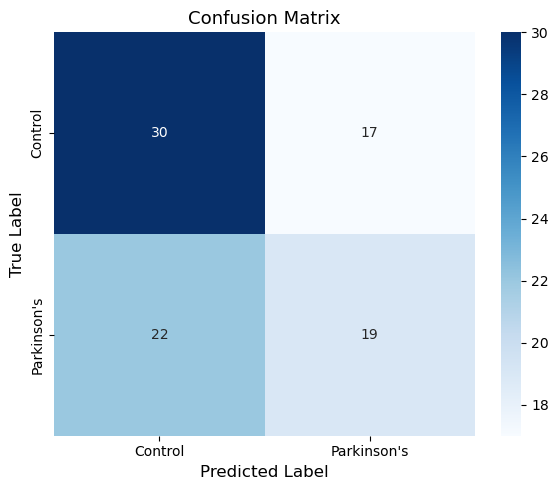

In [14]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Control", "Parkinson's"],
            yticklabels=["Control", "Parkinson's"])
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("Confusion Matrix", fontsize=13)
plt.tight_layout()
plt.show()

**The rows are the true labels and the columns are the predicted labels.**

- **Top left**: Control patients correctly predicted as Control (True Negatives)
- **Top right**: Control patients wrongly predicted as Parkinson's (False Positives)
- **Bottom left**: Parkinson's patients wrongly predicted as Control (False Negatives)
- **Bottom right**: Parkinson's patients correctly predicted as Parkinson's (True Positives)

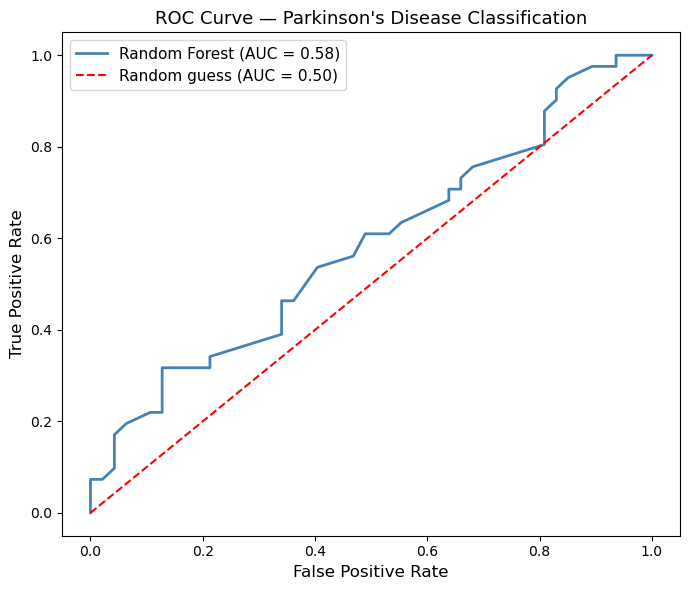

AUC Score: 0.584


In [15]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color="steelblue", linewidth=2, label=f"Random Forest (AUC = {auc:.2f})")
plt.plot([0, 1], [0, 1], color="red", linestyle="--", linewidth=1.5, label="Random guess (AUC = 0.50)")
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve — Parkinson\'s Disease Classification", fontsize=13)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"AUC Score: {auc:.3f}")

**The ROC curve shows the tradeoff between:**
- True Positive Rate (how many PD patients we correctly catch)
- False Positive Rate (how many Control patients we wrongly flag as PD)
- AUC (Area Under the Curve) summarizes this in one number: AUC = 1.0 is a perfect model, AUC = 0.5 means the model is no better than random guessing

In [18]:
# Get feature importances from the trained model
importances = pd.Series(rf.feature_importances_, index=X.columns)

# Sort from most to least important
importances = importances.sort_values(ascending=False)

print("Top 5 most important components:")
print(importances.head())

Top 5 most important components:
PC4     0.051045
PC19    0.049296
PC2     0.044223
PC21    0.042043
PC24    0.041023
dtype: float64


## Conclusion

This project applied **a complete bioinformatics machine learning pipeline** 
to the GSE99039 dataset to classify Idiopathic Parkinson's Disease (IPD) 
patients from healthy controls using peripheral blood gene expression data.

Starting from a raw microarray dataset of 558 samples and 54,675 probes,
the data were filtered to retain only IPD and Control samples (438 total), technical artifacts (AFFX probes) were removed, variance-based feature 
selection was applied,data were standardized and compressed using PCA (30 components, 
80% variance explained). Then a Random Forest classifier was trained.

### Results
- **Test Accuracy**: 55.7% 
- **AUC Score**: 0.584 
- **Most important component**: PC4 

### What this project demonstrates
Despite the modest classification performance, this project successfully 
demonstrates a complete and reproducible bioinformatics ML workflow:
data loading → EDA → preprocessing → dimensionality reduction → classification.